# Notebook 04: Model Explainability

**HeartSense**: Heart Disease Risk Prediction for Early Clinical Decision Support

CSC8204: AI & ML | Group 6 | Uganda Christian University | Easter 2026

---

**Purpose:** SHAP analysis, feature importance comparison, LR coefficient interpretation, and error analysis.


**Workflow Step 9: Documentation, Reflection, and Limitations**

All visualizations here are pre-computed and saved for the Streamlit Explainability page.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from src.config import TARGET, ALL_FEATURES, RANDOM_STATE, STRESS_TEST_FEATURES
from src.explainability import (
    compute_shap_values, get_feature_importance_from_shap,
    extract_lr_coefficients, profile_misclassifications
)
from src.evaluation import compute_metrics
from src.artifacts import save_json, save_dataframe, save_pickle
from src.preprocessing import get_feature_names

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Load artifacts
split_data = joblib.load("../models/train_test_split.joblib")
X_train, X_test = split_data["X_train"], split_data["X_test"]
y_train, y_test = split_data["y_train"], split_data["y_test"]
feature_cols = split_data["feature_cols"]

lr_pipeline = joblib.load("../models/lr_pipeline.joblib")
rf_pipeline = joblib.load("../models/rf_pipeline.joblib")
xgb_pipeline = joblib.load("../models/xgb_pipeline.joblib")
best_pipeline = joblib.load("../models/best_model.joblib")

metadata = joblib.load("../models/model_metadata.json") if False else None
import json
with open("../models/model_metadata.json") as f:
    metadata = json.load(f)
best_key = metadata["selected_model"]
best_threshold = metadata["selected_threshold"]

model_names = {"lr": "Logistic Regression", "rf": "Random Forest", "xgb": "XGBoost"}
print(f"Best model: {model_names[best_key]}")
print(f"Threshold: {best_threshold}")

Best model: Random Forest
Threshold: 0.49


## Section 1: SHAP Analysis: Best Model

In [2]:
# Get preprocessed data and feature names
preprocessor = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["model"]
feature_names_out = get_feature_names(preprocessor)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Determine SHAP explainer type
if best_key in ["rf", "xgb"]:
    model_type = "tree"
else:
    model_type = "linear"

print(f"Computing SHAP values for {model_names[best_key]} ({model_type} explainer)...")
print(f"Features: {len(feature_names_out)}")

# Compute SHAP on test set (for explanation of predictions we already evaluated)
shap_values, explainer = compute_shap_values(
    model, X_test_transformed,
    feature_names=feature_names_out,
    model_type=model_type
)

print(f"SHAP values shape: {shap_values.values.shape}")
print("SHAP computation complete.")

Computing SHAP values for Random Forest (tree explainer)...
Features: 14


SHAP values shape: (184, 14, 2)
SHAP computation complete.


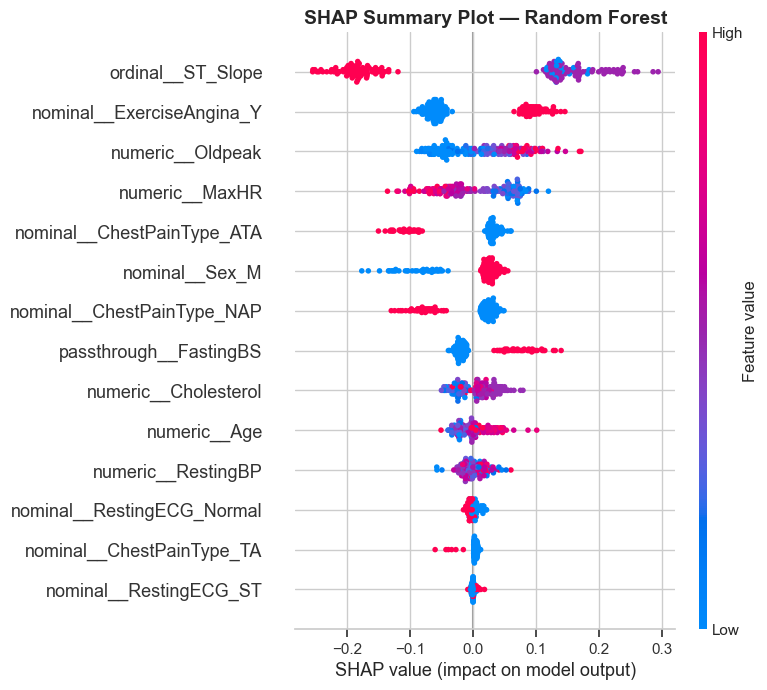

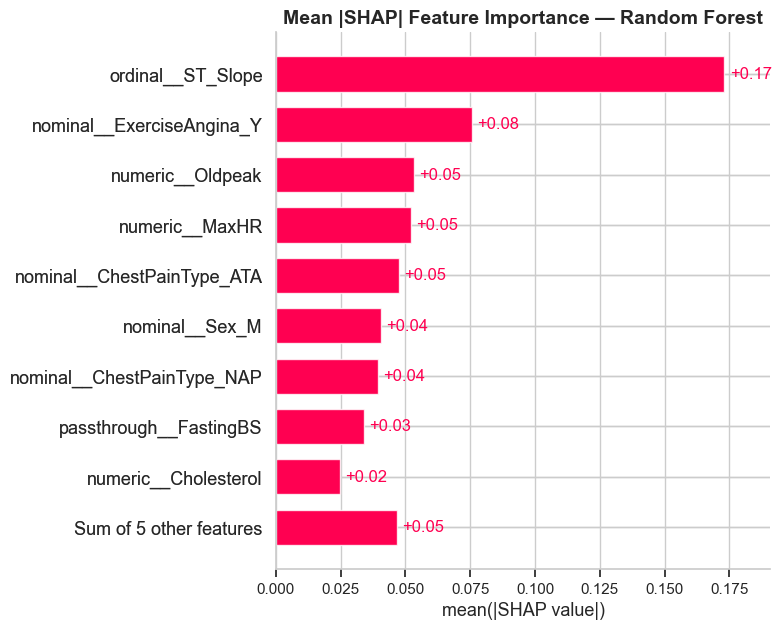

In [3]:
# Handle multi-output SHAP values (tree models may return shape [n, features, 2])
shap_vals = shap_values.values
if shap_vals.ndim == 3:
    # Take positive class (index 1)
    shap_display = shap.Explanation(
        values=shap_vals[:, :, 1],
        base_values=shap_values.base_values[:, 1] if shap_values.base_values.ndim > 1 else shap_values.base_values,
        data=shap_values.data,
        feature_names=feature_names_out
    )
else:
    shap_display = shap_values

# Global SHAP summary plot (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_display, show=False)
plt.title(f"SHAP Summary Plot — {model_names[best_key]}", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# SHAP bar plot (mean |SHAP|)
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_display, show=False)
plt.title(f"Mean |SHAP| Feature Importance — {model_names[best_key]}", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


  True Positive (correctly flagged) (index=0, prob=0.964, true=1)


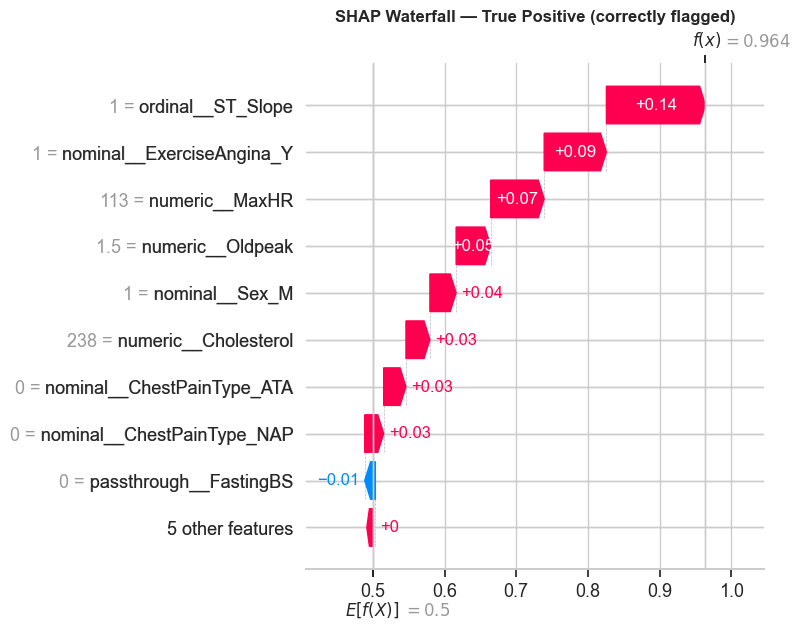


  False Negative (missed case) (index=1, prob=0.369, true=1)


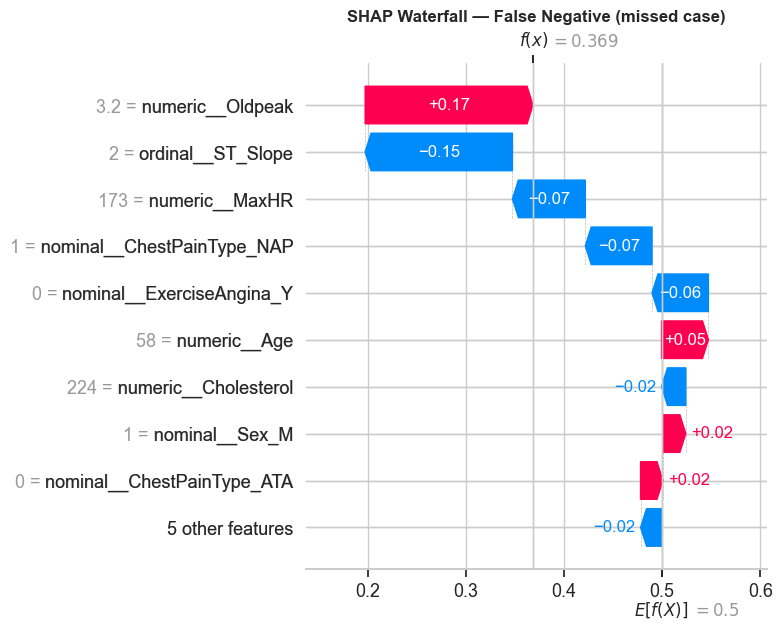


  Borderline Case (index=5, prob=0.440, true=0)


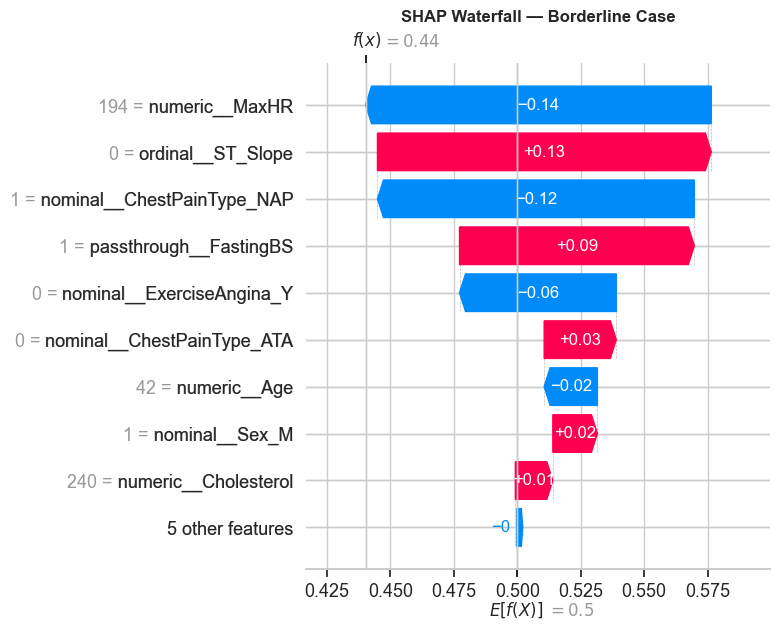

In [4]:
# Waterfall plots for sample patients
y_prob_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

# Find sample patients
tp_mask = (y_test.values == 1) & (y_pred_test == 1)
fn_mask = (y_test.values == 1) & (y_pred_test == 0)
borderline_mask = (y_prob_test >= 0.4) & (y_prob_test <= 0.6)

tp_indices = np.where(tp_mask)[0]
fn_indices = np.where(fn_mask)[0]
borderline_indices = np.where(borderline_mask)[0]

sample_patients = {}
if len(tp_indices) > 0:
    sample_patients["True Positive (correctly flagged)"] = tp_indices[0]
if len(fn_indices) > 0:
    sample_patients["False Negative (missed case)"] = fn_indices[0]
if len(borderline_indices) > 0:
    sample_patients["Borderline Case"] = borderline_indices[0]

for label, idx in sample_patients.items():
    print(f"\n{'='*60}")
    print(f"  {label} (index={idx}, prob={y_prob_test[idx]:.3f}, true={y_test.values[idx]})")
    print(f"{'='*60}")
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_display[idx], show=False)
    plt.title(f"SHAP Waterfall — {label}", fontweight="bold", fontsize=12)
    plt.tight_layout()
    safe_label = label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"../outputs/figures/shap_waterfall_{safe_label}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Section 2: Feature Importance Comparison Across Models

SHAP Feature Importance (mean |SHAP|):
                   feature  mean_abs_shap
         ordinal__ST_Slope       0.173088
 nominal__ExerciseAngina_Y       0.075756
          numeric__Oldpeak       0.053244
            numeric__MaxHR       0.052098
nominal__ChestPainType_ATA       0.047549
            nominal__Sex_M       0.040553
nominal__ChestPainType_NAP       0.039489
    passthrough__FastingBS       0.034072
      numeric__Cholesterol       0.024721
              numeric__Age       0.020228
        numeric__RestingBP       0.013660
nominal__RestingECG_Normal       0.005948
 nominal__ChestPainType_TA       0.004907
    nominal__RestingECG_ST       0.002054


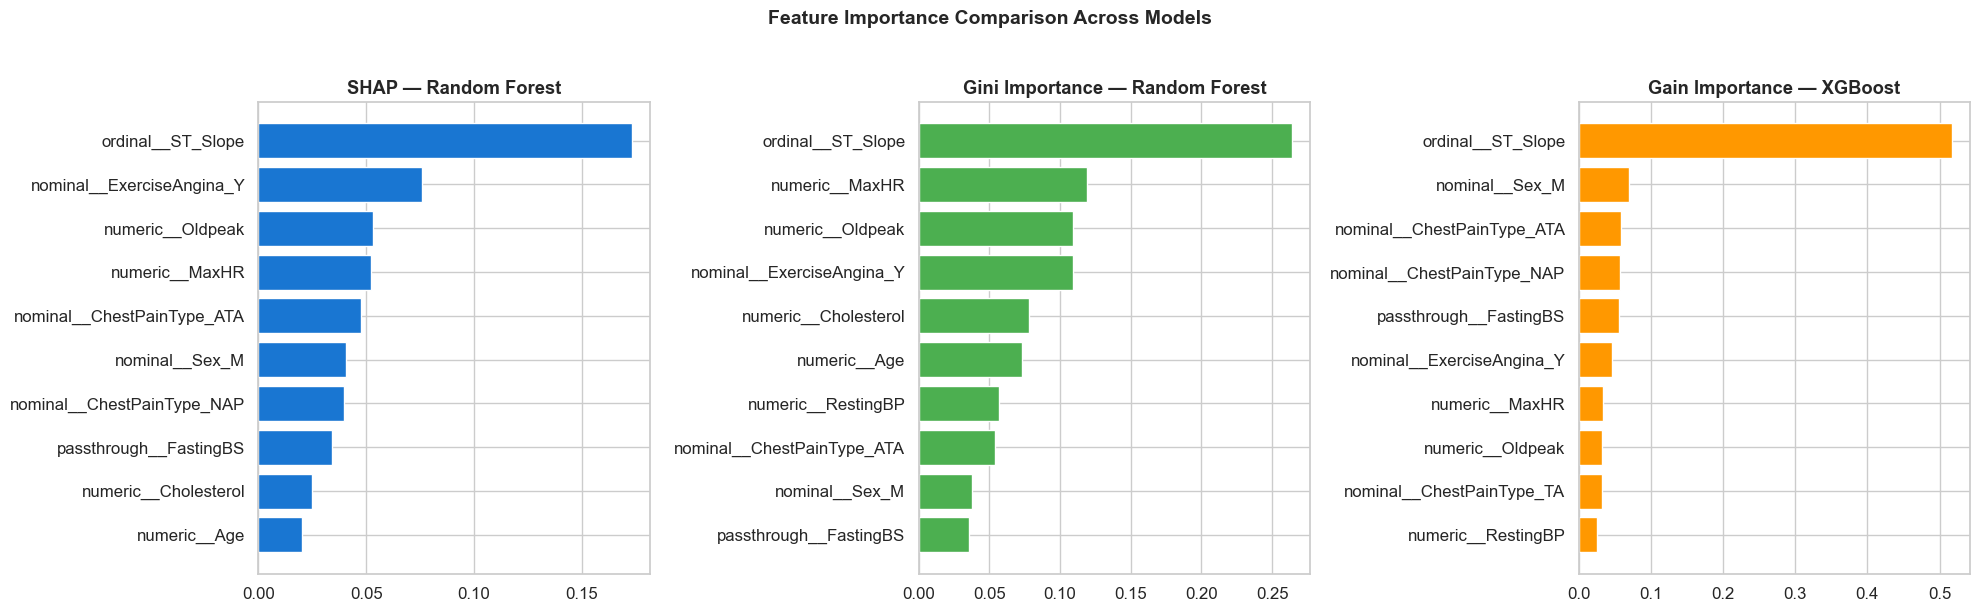


Note: 'Predictive contribution' does NOT imply causation.


In [5]:
# SHAP-based importance
shap_importance = get_feature_importance_from_shap(shap_display)
print("SHAP Feature Importance (mean |SHAP|):")
print(shap_importance.to_string(index=False))

# RF Gini importance
rf_model = rf_pipeline.named_steps["model"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_feature_names = get_feature_names(rf_preprocessor)
rf_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "gini_importance": rf_model.feature_importances_
}).sort_values("gini_importance", ascending=False).reset_index(drop=True)

# XGBoost gain importance
xgb_model = xgb_pipeline.named_steps["model"]
xgb_preprocessor = xgb_pipeline.named_steps["preprocessor"]
xgb_feature_names = get_feature_names(xgb_preprocessor)
xgb_importance = pd.DataFrame({
    "feature": xgb_feature_names,
    "gain_importance": xgb_model.feature_importances_
}).sort_values("gain_importance", ascending=False).reset_index(drop=True)

# Side-by-side top 10
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# SHAP
top_shap = shap_importance.head(10)
axes[0].barh(top_shap["feature"], top_shap["mean_abs_shap"], color="#1976D2")
axes[0].set_title(f"SHAP — {model_names[best_key]}", fontweight="bold")
axes[0].invert_yaxis()

# RF Gini
top_rf = rf_importance.head(10)
axes[1].barh(top_rf["feature"], top_rf["gini_importance"], color="#4CAF50")
axes[1].set_title("Gini Importance — Random Forest", fontweight="bold")
axes[1].invert_yaxis()

# XGBoost gain
top_xgb = xgb_importance.head(10)
axes[2].barh(top_xgb["feature"], top_xgb["gain_importance"], color="#FF9800")
axes[2].set_title("Gain Importance — XGBoost", fontweight="bold")
axes[2].invert_yaxis()

plt.suptitle("Feature Importance Comparison Across Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nNote: 'Predictive contribution' does NOT imply causation.")

## Section 3: Logistic Regression Coefficients

Logistic Regression Coefficients:
                   feature  coefficient  abs_coefficient      direction
         ordinal__ST_Slope    -1.508965         1.508965 Decreases risk
 nominal__ExerciseAngina_Y     0.815920         0.815920 Increases risk
nominal__ChestPainType_ATA    -0.772677         0.772677 Decreases risk
nominal__ChestPainType_NAP    -0.664241         0.664241 Decreases risk
            nominal__Sex_M     0.598331         0.598331 Increases risk
    passthrough__FastingBS     0.503690         0.503690 Increases risk
            numeric__MaxHR    -0.387880         0.387880 Decreases risk
          numeric__Oldpeak     0.165448         0.165448 Increases risk
              numeric__Age     0.000000         0.000000 Decreases risk
        numeric__RestingBP     0.000000         0.000000 Decreases risk
      numeric__Cholesterol     0.000000         0.000000 Decreases risk
 nominal__ChestPainType_TA     0.000000         0.000000 Decreases risk
nominal__RestingECG_Normal    

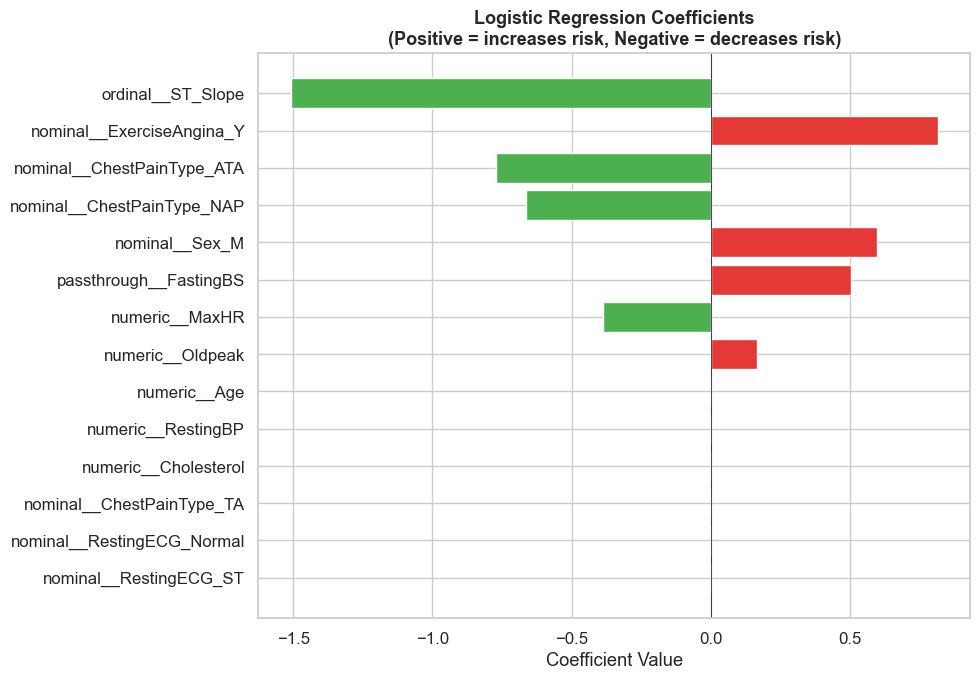

Saved CSV: ..\outputs\tables\lr_coefficients.csv

Caveat: Coefficients reflect association within the model,
not causal clinical drivers. Features are post-scaling.


In [6]:
# Extract LR coefficients
lr_feature_names = get_feature_names(lr_pipeline.named_steps["preprocessor"])
coef_df = extract_lr_coefficients(lr_pipeline, lr_feature_names)

print("Logistic Regression Coefficients:")
print(coef_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 7))
colors_coef = ["#E53935" if c > 0 else "#4CAF50" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors_coef)
ax.set_xlabel("Coefficient Value")
ax.set_title("Logistic Regression Coefficients\n(Positive = increases risk, Negative = decreases risk)",
             fontweight="bold", fontsize=13)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

save_dataframe(coef_df, "../outputs/tables", "lr_coefficients.csv")

print("\nCaveat: Coefficients reflect association within the model,")
print("not causal clinical drivers. Features are post-scaling.")

## Section 4: Error Analysis

In [7]:
# Profile misclassified cases from the best model on test set
fn_profile, fp_profile, fn_cases, fp_cases = profile_misclassifications(
    X_test, y_test, y_pred_test
)

print(f"Test set size: {len(y_test)}")
print(f"False Negatives (missed disease): {len(fn_cases)}")
print(f"False Positives (unnecessary referral): {len(fp_cases)}")

print("\n" + "="*60)
print("FALSE NEGATIVE PROFILE (missed heart disease cases)")
print("="*60)
if len(fn_cases) > 0:
    print(fn_cases[feature_cols].describe().round(2))
    print(f"\nSample false negatives:")
    print(fn_cases[feature_cols].head(5))
else:
    print("No false negatives at this threshold.")

print("\n" + "="*60)
print("FALSE POSITIVE PROFILE (unnecessary referrals)")
print("="*60)
if len(fp_cases) > 0:
    print(fp_cases[feature_cols].describe().round(2))
    print(f"\nSample false positives:")
    print(fp_cases[feature_cols].head(5))
else:
    print("No false positives at this threshold.")

Test set size: 184
False Negatives (missed disease): 12
False Positives (unnecessary referral): 10

FALSE NEGATIVE PROFILE (missed heart disease cases)
         Age  RestingBP  Cholesterol  FastingBS   MaxHR  Oldpeak  BP_Category  \
count  12.00      11.00         8.00      12.00   12.00    12.00        11.00   
mean   54.08     140.09       226.25       0.08  155.67     0.93         1.45   
std     6.27      27.71        32.87       0.29   24.16     1.17         0.82   
min    47.00     108.00       180.00       0.00   98.00     0.00         0.00   
25%    48.75     124.00       207.00       0.00  151.50     0.00         1.00   
50%    53.00     132.00       218.00       0.00  156.00     0.45         2.00   
75%    58.25     150.00       246.25       0.00  164.75     1.50         2.00   
max    66.00     192.00       283.00       1.00  195.00     3.20         2.00   

       HighCholesterol  
count             8.00  
mean              0.38  
std               0.52  
min               

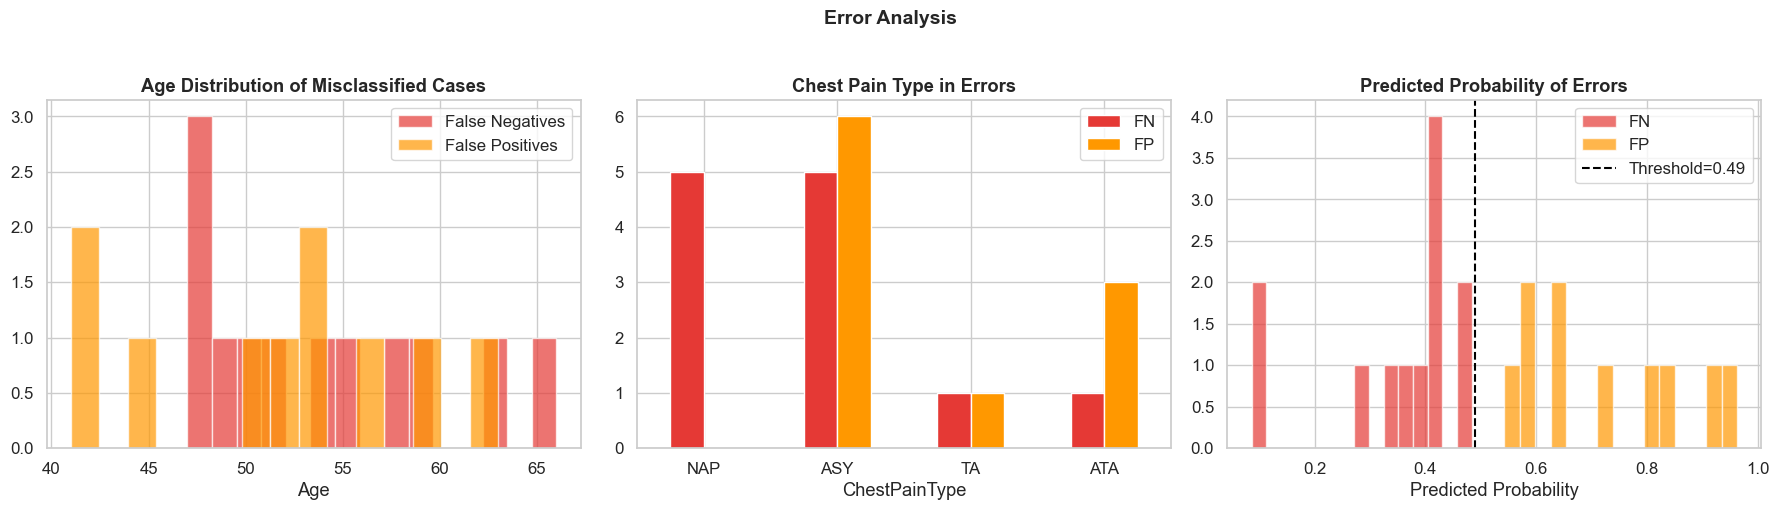


Clinical implications:
- False negatives: missed heart disease patients who would not be referred.
  These are the most clinically dangerous errors in a screening context.
- False positives: healthy patients flagged for unnecessary referral.
  This increases referral burden but does not directly harm patients.


In [8]:
# Visualize error patterns
if len(fn_cases) > 0 or len(fp_cases) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Age distribution of errors
    if len(fn_cases) > 0:
        axes[0].hist(fn_cases["Age"], bins=15, alpha=0.7, color="#E53935", label="False Negatives", edgecolor="white")
    if len(fp_cases) > 0:
        axes[0].hist(fp_cases["Age"], bins=15, alpha=0.7, color="#FF9800", label="False Positives", edgecolor="white")
    axes[0].set_title("Age Distribution of Misclassified Cases", fontweight="bold")
    axes[0].set_xlabel("Age")
    axes[0].legend()
    
    # Chest pain type of errors
    error_labels = []
    error_data = []
    if len(fn_cases) > 0:
        fn_cp = fn_cases["ChestPainType"].value_counts()
        error_labels.append("FN")
        error_data.append(fn_cp)
    if len(fp_cases) > 0:
        fp_cp = fp_cases["ChestPainType"].value_counts()
        error_labels.append("FP")
        error_data.append(fp_cp)
    
    if error_data:
        error_cp_df = pd.DataFrame(error_data, index=error_labels).fillna(0)
        error_cp_df.T.plot(kind="bar", ax=axes[1], color=["#E53935", "#FF9800"][:len(error_labels)], rot=0)
        axes[1].set_title("Chest Pain Type in Errors", fontweight="bold")
    
    # Probability distribution of errors
    fn_probs = y_prob_test[np.where((y_test.values == 1) & (y_pred_test == 0))[0]]
    fp_probs = y_prob_test[np.where((y_test.values == 0) & (y_pred_test == 1))[0]]
    if len(fn_probs) > 0:
        axes[2].hist(fn_probs, bins=15, alpha=0.7, color="#E53935", label="FN", edgecolor="white")
    if len(fp_probs) > 0:
        axes[2].hist(fp_probs, bins=15, alpha=0.7, color="#FF9800", label="FP", edgecolor="white")
    axes[2].axvline(x=best_threshold, color="black", linestyle="--", label=f"Threshold={best_threshold}")
    axes[2].set_title("Predicted Probability of Errors", fontweight="bold")
    axes[2].set_xlabel("Predicted Probability")
    axes[2].legend()
    
    plt.suptitle("Error Analysis", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("../outputs/figures/error_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

print("\nClinical implications:")
print("- False negatives: missed heart disease patients who would not be referred.")
print("  These are the most clinically dangerous errors in a screening context.")
print("- False positives: healthy patients flagged for unnecessary referral.")
print("  This increases referral burden but does not directly harm patients.")

## Section 5: Save Explainability Artifacts

In [9]:
# Save SHAP values and explainer
save_pickle(shap_display, "../outputs/shap", "shap_values.pkl")
save_pickle(explainer, "../outputs/shap", "shap_explainer.pkl")

# Save sample patient data for Streamlit waterfall display
sample_data = {}
for label, idx in sample_patients.items():
    sample_data[label] = {
        "index": int(idx),
        "probability": round(float(y_prob_test[idx]), 4),
        "true_label": int(y_test.values[idx]),
        "predicted": int(y_pred_test[idx]),
        "features": X_test.iloc[idx].to_dict(),
    }
save_json(sample_data, "../outputs/app_assets", "sample_patients.json")

# Save feature importance tables
save_dataframe(shap_importance, "../outputs/tables", "shap_importance.csv")
save_dataframe(rf_importance, "../outputs/tables", "rf_importance.csv")
save_dataframe(xgb_importance, "../outputs/tables", "xgb_importance.csv")

# Save error analysis data
error_summary = {
    "n_test": int(len(y_test)),
    "n_fn": int(len(fn_cases)),
    "n_fp": int(len(fp_cases)),
    "threshold": best_threshold,
}
save_json(error_summary, "../outputs/app_assets", "error_summary.json")

# Save background data for live SHAP in Streamlit (subsample for speed)
bg_sample_size = min(100, X_train_transformed.shape[0])
bg_indices = np.random.RandomState(RANDOM_STATE).choice(
    X_train_transformed.shape[0], bg_sample_size, replace=False
)
save_pickle({
    "background_data": X_train_transformed[bg_indices],
    "feature_names": feature_names_out,
    "model_type": model_type,
}, "../outputs/shap", "shap_background.pkl")

print("\nAll explainability artifacts saved successfully.")
print(f"  SHAP values: ../outputs/shap/")
print(f"  Figures: ../outputs/figures/")
print(f"  Tables: ../outputs/tables/")
print(f"  App assets: ../outputs/app_assets/")

Saved pickle: ..\outputs\shap\shap_values.pkl


Saved pickle: ..\outputs\shap\shap_explainer.pkl
Saved JSON: ..\outputs\app_assets\sample_patients.json
Saved CSV: ..\outputs\tables\shap_importance.csv
Saved CSV: ..\outputs\tables\rf_importance.csv
Saved CSV: ..\outputs\tables\xgb_importance.csv
Saved JSON: ..\outputs\app_assets\error_summary.json
Saved pickle: ..\outputs\shap\shap_background.pkl

All explainability artifacts saved successfully.
  SHAP values: ../outputs/shap/
  Figures: ../outputs/figures/
  Tables: ../outputs/tables/
  App assets: ../outputs/app_assets/
